Text(0.5, 1.0, "$ y' = - \\frac{x^2}{1 - x^2 - y^2} $")

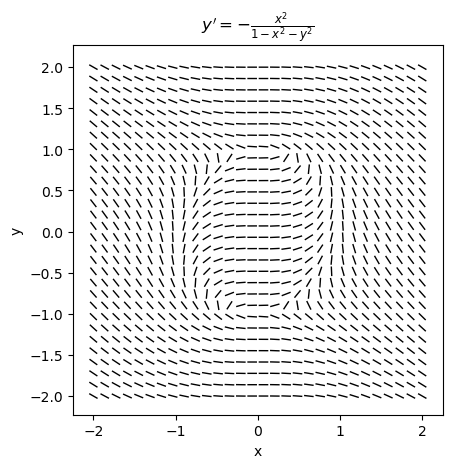

In [12]:
import numpy as np
# numpy: untuk operasi numerik (array, meshgrid, trigonometrik, dll)

from matplotlib import pyplot as plt
# matplotlib: untuk membuat visualisasi grafik


# =========================
# Direction Field Function
# =========================
def direction_field(x_min, x_max, y_min, y_max, n_step, length, fun, ax):
    # fungsi untuk membuat direction field (field garis arah ODE)

    np.seterr(divide='ignore', invalid='ignore')
    # menonaktifkan warning pembagian nol atau nilai tidak valid

    x = np.linspace(x_min, x_max, n_step)
    # membuat grid nilai x

    y = np.linspace(y_min, y_max, n_step)
    # membuat grid nilai y

    X, Y = np.meshgrid(x, y)
    # membuat grid 2D (kombinasi semua titik (x,y))

    slope = fun(X, Y)
    # menghitung kemiringan (dy/dx) di setiap titik grid

    slope = np.where(slope == np.inf, 10**3, slope)
    # mengganti nilai inf menjadi angka besar (stabilisasi numerik)

    slope = np.where(slope == -np.inf, -10**3, slope)
    # mengganti -inf menjadi angka besar negatif

    delta = length * np.cos(np.arctan(slope))
    # komponen arah horizontal dari garis kecil

    X1 = X - delta
    X2 = X + delta
    # titik awal dan akhir segmen garis kecil

    Y1 = slope * (X1 - X) + Y
    Y2 = slope * (X2 - X) + Y
    # menghitung perubahan y berdasarkan slope (garis singgung)

    ax.plot([X1.ravel(), X2.ravel()],
            [Y1.ravel(), Y2.ravel()],
            'k-', linewidth=1)
    # menggambar segmen kecil arah medan (direction field)


# =========================
# Differential Equation
# =========================
def my_ode(x, y):
    # definisi persamaan diferensial dy/dx

    dy_dx = x**2 / (1 - x**2 - y**2)
    # fungsi gradien (slope field)

    return dy_dx
    # mengembalikan nilai turunan


# =========================
# Plotting
# =========================
fig, ax1 = plt.subplots()
# membuat figure dan axes

direction_field(x_min=-2, x_max=2,
                y_min=-2, y_max=2,
                n_step=30,
                length=0.05,
                fun=my_ode,
                ax=ax1)
# membuat direction field untuk ODE

ax1.set_xlabel('x')
# label sumbu x

ax1.set_ylabel('y')
# label sumbu y

ax1.axis('square')
# membuat skala sumbu x dan y sama (biar tidak terdistorsi)

ax1.set_title(r"$ y' = - \frac{x^2}{1 - x^2 - y^2} $")
# judul plot (persamaan diferensial)

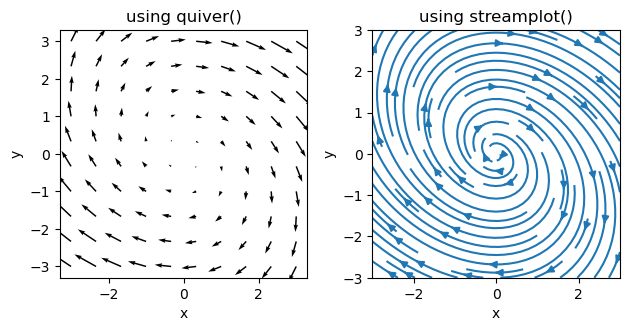

In [13]:
import numpy as np
# numpy dipakai untuk membuat grid dan operasi vektor

import matplotlib.pyplot as plt
# matplotlib untuk visualisasi grafik


# =========================
# Membuat grid titik (x, y)
# =========================
x = np.linspace(-3, 3, 10)
# membuat 10 titik dari -3 sampai 3

y = x
# membuat y sama seperti x (grid simetris)

X, Y = np.meshgrid(x, y)
# membuat grid 2D semua kombinasi (x, y)


# =========================
# Definisi medan vektor
# =========================
dx_dt = X + 2*Y
# komponen arah sumbu x (vektor field)

dy_dt = -2*X
# komponen arah sumbu y (vektor field)


# =========================
# Plotting
# =========================
fig = plt.figure()
# membuat figure kosong


# -------------------------
# 1. QUIVER PLOT
# -------------------------
ax1 = fig.add_subplot(1, 2, 1)
# subplot 1 dari 2 (kiri)

ax1.quiver(X, Y, dx_dt, dy_dt)
# menggambar vektor sebagai panah di tiap titik grid

ax1.set_title('using quiver()')
# judul plot

ax1.set_xlabel('x')
# label sumbu x

ax1.set_ylabel('y')
# label sumbu y

ax1.axis('square')
# skala x dan y dibuat sama


# -------------------------
# 2. STREAM PLOT
# -------------------------
ax2 = fig.add_subplot(1, 2, 2)
# subplot 2 dari 2 (kanan)

ax2.streamplot(X, Y, dx_dt, dy_dt)
# menggambar garis aliran (trajectory field)

ax2.set_title('using streamplot()')
# judul plot

ax2.set_xlabel('x')
# label x

ax2.set_ylabel('y')
# label y

ax2.axis('square')
# skala sama


fig.tight_layout()
# merapikan layout supaya tidak overlap

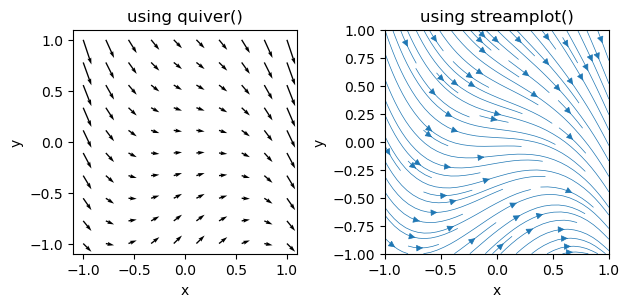

In [14]:
import numpy as np
# library numerik untuk array dan operasi matematika

import matplotlib.pyplot as plt
# library visualisasi grafik


# =========================
# Membuat grid (x, y)
# =========================
x = np.linspace(-1, 1, 10)
# 10 titik dari -1 sampai 1

y = x
# membuat grid simetris

X, Y = np.meshgrid(x, y)
# membuat grid 2D semua kombinasi (x, y)


# =========================
# Definisi sistem ODE
# =========================
dx_dt = np.ones_like(X)
# dx/dt = 1 → gerakan selalu ke kanan (konstan)

dy_dt = -Y - 2 * X**2
# dy/dt = -y - 2x²
# kombinasi linear + non-linear (x²)


# =========================
# Visualisasi
# =========================
fig = plt.figure()
# membuat figure kosong


# -------------------------
# QUIVER PLOT (panah)
# -------------------------
ax1 = fig.add_subplot(1, 2, 1)
# subplot kiri

ax1.quiver(X, Y, dx_dt, dy_dt)
# menampilkan vektor arah di setiap titik

ax1.set_title('using quiver()')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.axis('square')
# membuat skala sumbu sama


# -------------------------
# STREAM PLOT (aliran)
# -------------------------
ax2 = fig.add_subplot(1, 2, 2)
# subplot kanan

ax2.streamplot(X, Y, dx_dt, dy_dt, linewidth=0.5)
# garis aliran yang mengikuti field vektor

ax2.set_title('using streamplot()')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.axis('square')


fig.tight_layout()
# merapikan layout agar tidak overlap

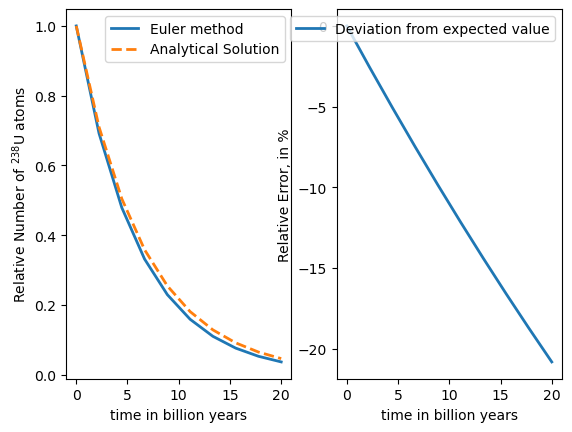

In [15]:
import matplotlib.pyplot as plt
# matplotlib: untuk membuat grafik

import numpy as np
# numpy: untuk operasi numerik dan array


# =========================
# Euler Method (numerik)
# =========================
def euler_method(n0, decay_const, t_final, n_t_steps):
    # metode Euler untuk solusi persamaan peluruhan radioaktif

    iterations = n_t_steps
    # jumlah langkah iterasi

    delta_t = t_final / n_t_steps
    # ukuran langkah waktu (Δt)

    t1 = np.linspace(0, iterations * delta_t, iterations)
    # membuat array waktu

    n1 = np.zeros(t1.shape, float)
    # array kosong untuk jumlah partikel

    n1[0] = n0
    # kondisi awal (jumlah awal atom)

    for i in range(0, len(t1) - 1):
        # iterasi Euler

        n1[i+1] = n1[i] * (1 - decay_const * delta_t)
        # rumus Euler:
        # n(t+Δt) = n(t) + dn/dt * Δt
        # dengan dn/dt = -λn

    n1r = n1 / n0
    # normalisasi terhadap nilai awal

    return n1, n1r, t1
    # mengembalikan hasil absolut, relatif, dan waktu


ne, ner, te = euler_method(
    n0=10000,
    decay_const=1.54e-1,
    t_final=20,
    n_t_steps=10
)
# menjalankan metode Euler


# =========================
# Solusi Analitik
# =========================
def analytical_solution(n0, decay_const, t_final, n_t_steps):
    # solusi eksak dari peluruhan eksponensial

    intermediate_points = n_t_steps
    delta_t = t_final / n_t_steps

    t2 = np.linspace(0, intermediate_points * delta_t, intermediate_points)
    # grid waktu yang sama dengan Euler

    n2 = n0 * np.exp(-decay_const * t2)
    # solusi eksak: n(t) = n0 e^(-λt)

    n2r = n2 / n0
    # normalisasi

    return n2, n2r, t2
    # mengembalikan hasil


na, nar, ta = analytical_solution(
    n0=10000,
    decay_const=1.54e-1,
    t_final=20,
    n_t_steps=10
)
# menjalankan solusi analitik


# =========================
# Error relatif Euler
# =========================
euler_rel_error = 100 * (ne - na) / na
# menghitung error relatif (%)


# =========================
# Plot hasil
# =========================
fig = plt.figure()
# membuat figure

# -------------------------
# Plot 1: solusi
# -------------------------
ax1 = fig.add_subplot(1, 2, 1)
# subplot kiri

ax1.plot(te, ner, linestyle="-", linewidth=2, label='Euler method')
# hasil Euler

ax1.plot(ta, nar, linestyle="--", linewidth=2, label='Analytical Solution')
# hasil analitik

ax1.set_ylabel('Relative Number of $^{238}$U atoms')
# label sumbu y

ax1.set_xlabel('time in billion years')
# label sumbu x

ax1.legend()
# menampilkan legenda


# -------------------------
# Plot 2: error
# -------------------------
ax2 = fig.add_subplot(1, 2, 2)
# subplot kanan

ax2.plot(te, euler_rel_error,
         linestyle="-",
         linewidth=2,
         label='Deviation from expected value')
# grafik error Euler

ax2.set_ylabel('Relative Error, in %')
# label y

ax2.set_xlabel('time in billion years')
# label x

ax2.legend()
# legenda

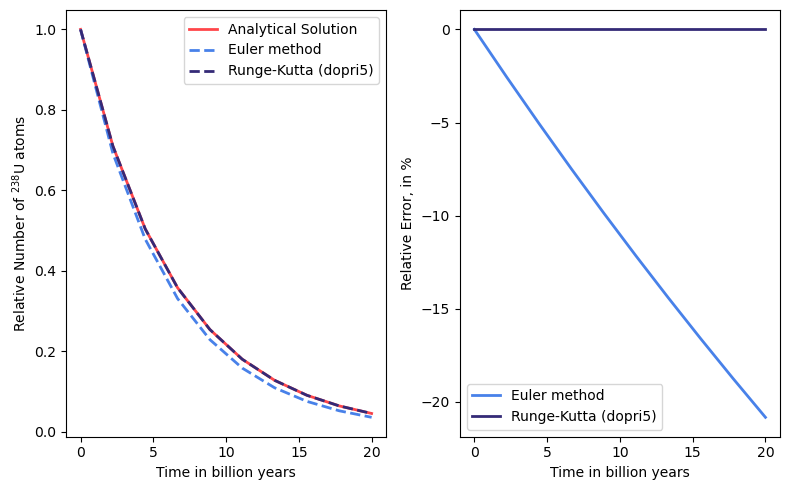

In [16]:
import matplotlib.pyplot as plt
# untuk membuat grafik

import numpy as np
# untuk operasi numerik

from scipy.integrate import ode
# solver ODE (Runge-Kutta adaptif dari SciPy)


# =========================
# SOLVER ODE (Runge-Kutta)
# =========================
def ode_sol(n0, decay_const, t_final, n_t_steps):
    # menyelesaikan ODE peluruhan radioaktif dengan solver SciPy

    intermediate_points = n_t_steps
    # jumlah titik waktu

    t3 = np.linspace(0, t_final, intermediate_points)
    # grid waktu

    n3 = np.zeros(t3.shape, float)
    # array hasil

    # -------------------------
    # definisi ODE
    # -------------------------
    def f(t, y, decay_const):
        return -decay_const * y
        # dn/dt = -λn (eksponensial decay)

    solver = ode(f).set_integrator('dopri5')
    # solver Runge-Kutta adaptif orde 4(5)

    y0 = n0
    t0 = 0

    solver.set_initial_value(y0, t0)
    # set kondisi awal

    solver.set_f_params(decay_const)
    # parameter λ dimasukkan ke fungsi ODE

    k = 1
    n3[0] = n0
    # nilai awal

    # -------------------------
    # integrasi numerik
    # -------------------------
    while solver.successful() and solver.t < t_final:
        n3[k] = solver.integrate(t3[k])[0]
        # integrasi sampai titik waktu berikutnya
        k += 1

    n3r = n3 / n0
    # normalisasi

    return n3, n3r, t3
    # return hasil


# =========================
# SOLUSI ANALITIK
# =========================
na, nar, ta = analytical_solution(
    n0=10000,
    decay_const=1.54e-1,
    t_final=20,
    n_t_steps=10
)
# solusi eksak


# =========================
# EULER METHOD
# =========================
ne, ner, te = euler_method(
    n0=10000,
    decay_const=1.54e-1,
    t_final=20,
    n_t_steps=10
)
# solusi Euler


euler_rel_error = 100 * (ne - na) / na
# error Euler


# =========================
# RUNGE-KUTTA (SciPy ode)
# =========================
n_ode, n_oder, tode = ode_sol(
    n0=10000,
    decay_const=1.54e-1,
    t_final=20,
    n_t_steps=10
)
# solusi RK adaptif

ode_rel_error = 100 * (n_ode - na) / na
# error RK


# =========================
# PLOT HASIL
# =========================
fig = plt.figure(figsize=(8, 5))
# membuat figure


# -------------------------
# plot solusi
# -------------------------
ax1 = fig.add_subplot(1, 2, 1)

ax1.plot(ta, nar,
         linestyle="-",
         linewidth=2,
         label='Analytical Solution',
         c='#ff464a')

ax1.plot(te, ner,
         linestyle="--",
         linewidth=2,
         label='Euler method',
         c='#4881e9')

ax1.plot(tode, n_oder,
         linestyle="--",
         linewidth=2,
         label='Runge-Kutta (dopri5)',
         c='#342a77')

ax1.set_ylabel('Relative Number of $^{238}$U atoms')
ax1.set_xlabel('Time in billion years')
ax1.legend()


# -------------------------
# plot error
# -------------------------
ax2 = fig.add_subplot(1, 2, 2)

ax2.plot(te, euler_rel_error,
         linestyle="-",
         linewidth=2,
         c='#4881e9',
         label='Euler method')

ax2.plot(tode, ode_rel_error,
         linestyle="-",
         linewidth=2,
         c='#342a77',
         label='Runge-Kutta (dopri5)')

ax2.set_ylabel('Relative Error, in %')
ax2.set_xlabel('Time in billion years')
ax2.legend()


fig.tight_layout()
# merapikan layout

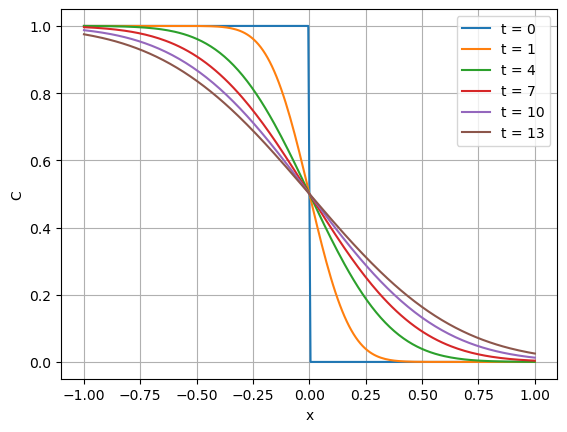

In [17]:
import numpy as np
# numpy: untuk array dan operasi numerik

from scipy import special
# scipy.special: menyediakan fungsi matematika khusus (di sini erfc)

import matplotlib.pyplot as plt
# matplotlib: untuk membuat grafik


# =========================
# Solusi difusi 1D (semi-infinite plane)
# =========================
def plane_diff_1d(t, D, x0=0, xmin=-1, xmax=1,
                   c_left=1, c_right=0, num_points=200):
    # model difusi 1D dengan kondisi awal step function

    n = num_points
    # jumlah titik grid

    x = np.linspace(xmin, xmax, n)
    # domain spasial

    delta_c = c_left - c_right
    # selisih konsentrasi awal

    # -------------------------
    # kondisi awal (t = 0)
    # -------------------------
    c0 = np.piecewise(x,
                      [x < x0, x >= x0],
                      [c_left, c_right])
    # step function: kiri = c_left, kanan = c_right

    # -------------------------
    # solusi analitik difusi
    # -------------------------
    c = 0.5 * delta_c * special.erfc(
        (x - x0) / (2 * np.sqrt(D * t))
    )
    # solusi persamaan difusi 1D (error function solution)

    return x, c, c0
    # mengembalikan grid x, solusi c(t), dan kondisi awal


# =========================
# parameter difusi
# =========================
D = 0.01
# koefisien difusi


# =========================
# plotting evolusi waktu
# =========================
fig, ax = plt.subplots()
# membuat figure


for t in range(1, 14, 3):
    # loop waktu: 1, 4, 7, 10, 13

    x, c, c0 = plane_diff_1d(t=t, D=D)
    # hitung profil konsentrasi

    if t == 1:
        plt.plot(x, c0, label="t = 0")
        # plot kondisi awal (step function)

    leg = "t = " + str(t)
    # label waktu

    ax.plot(x, c, label=leg)
    # plot solusi difusi


ax.grid()
# menambahkan grid

ax.set_xlabel('x')
# label sumbu x

ax.set_ylabel('C')
# label sumbu y

ax.legend()
# menampilkan legenda

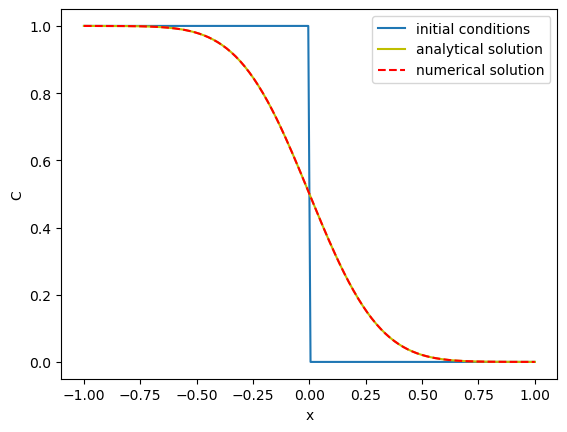

In [ ]:
import numpy as np
# numpy: untuk array dan operasi numerik

import matplotlib.pyplot as plt
# matplotlib: untuk plotting

# FTCS (Finite Difference)
def ftcs(u, D, h, dt):
    # metode numerik eksplisit untuk persamaan difusi 1D

    d2u_dx2 = np.zeros(u.shape, float)
    # array untuk turunan kedua ruang (∂²u/∂x²)

    # -------------------------
    # central difference (interior)
    # -------------------------
    for i in range(1, len(u) - 1):
        d2u_dx2[i] = (u[i+1] - 2*u[i] + u[i-1]) / h**2
        # aproksimasi turunan kedua (finite difference pusat)

    # -------------------------
    # boundary conditions (Neumann)
    # -------------------------
    i = 0
    d2u_dx2[i] = (u[i+1] - 2*u[i] + u[i]) / h**2
    # batas kiri

    i = len(u) - 1
    d2u_dx2[i] = (u[i] - 2*u[i] + u[i-1]) / h**2
    # batas kanan

    # -------------------------
    # update waktu (Euler eksplisit)
    # -------------------------
    u1 = u + dt * D * d2u_dx2
    # u(t+dt) = u(t) + D * ∂²u/∂x² * dt

    return u1
    # hasil setelah satu langkah waktu

# simulasi waktu total
dt = 0.001
# langkah waktu kecil (stabilitas numerik)

tf = 3
# waktu akhir simulasi

def compute_d_const(u, d, h, dt, tf):
    # menjalankan FTCS untuk banyak langkah waktu

    nsteps = tf / dt
    # jumlah iterasi waktu

    u1 = u
    # kondisi awal

    for i in range(int(nsteps)):
        u1 = ftcs(u1, D, h, dt)
        # iterasi difusi

    return u1
    # hasil akhir

# kondisi awal analitik
x, c, c0 = plane_diff_1d(t=tf, D=D)
# solusi analitik difusi

h = x[1] - x[0]
# jarak grid ruang

u = c0
# kondisi awal numerik (step function)

# solusi numerik FTCS
c1 = compute_d_const(u, D, h, dt, tf)
# hasil simulasi numerik

# plotting
fig, ax = plt.subplots()
# membuat figure

ax.plot(x, c0, label='initial conditions')
# kondisi awal

ax.plot(x, c, 'y', label='analytical solution')
# solusi analitik

ax.plot(x, c1, 'r--', label='numerical solution')
# solusi FTCS

ax.set_xlabel('x')
# label sumbu x

ax.set_ylabel('C')
# label sumbu y

ax.legend()
# legenda

In [ ]:
def numpy_ftcs(u, D, h, dt):

    # Inisialisasi array turunan kedua ruang
    d2u_dx2 = np.zeros(u.shape, float)

    # Skema beda hingga pusat (central difference)
    # untuk titik interior domain
    d2u_dx2[1:-1] = (u[2:] - 2 * u[1:-1] + u[:-2]) / h**2

    # Kondisi batas Neumann (tidak ada fluks / gradien nol)

    # batas kiri (i = 0)
    i = 0
    d2u_dx2[i] = (u[i+1] - 2 * u[i] + u[i]) / h**2

    # batas kanan (i = akhir)
    i = len(u) - 1
    d2u_dx2[i] = (u[i] - 2 * u[i] + u[i-1]) / h**2

    # Skema Euler eksplisit untuk waktu
    # u(t+dt) = u(t) + dt * D * ∂²u/∂x²
    u1 = u + dt * D * d2u_dx2

    return u1

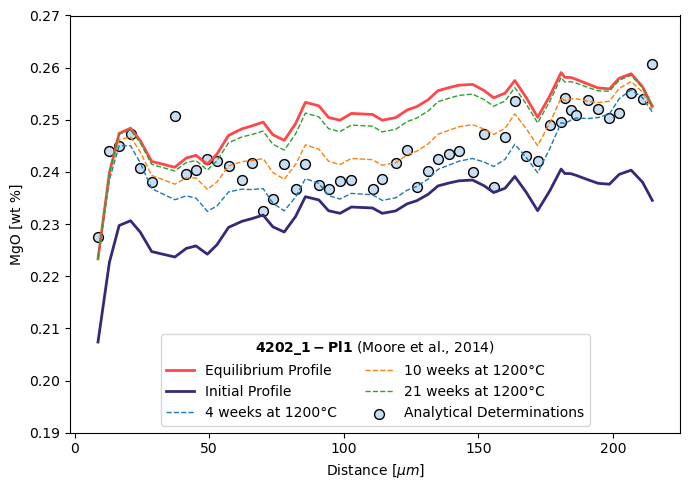

In [ ]:
import numpy as np
# numpy: untuk array dan operasi numerik

import matplotlib.pyplot as plt
# matplotlib: untuk plotting grafik

import pandas as pd
# pandas: untuk membaca dan mengolah data Excel

# PARAMETER MODEL DIFUSI KIMIA
T = 1200.0
# suhu sistem (°C)

dx = 4.12
# jarak antar titik data (mikron)

dt = 0.9 * 1e4
# langkah waktu numerik (detik)

RT = 8.3144 * (T + 273.15)
# konstanta gas * temperatur (Kelvin)

R = dt / dx**2
# parameter numerik (kontrol stabilitas difusi)

# DATA AWAL
my_dataset = pd.read_excel('Moore_Phd.xlsx')
# membaca data eksperimen

my_distance = my_dataset.Distance.values
# posisi dalam mikron

Mg_C = my_dataset.MgO.values
# data MgO hasil pengukuran

An = my_dataset.An_mol_percent.values
# komposisi An (mol %)

An = An / 100
# konversi ke fraksi

An_unsmoothed = An
# profil awal An

An_smoothed = np.full(len(An), 0.)
# array untuk smoothing

# SMOOTHING PROFIL AN
D_smoot = np.full(len(An), 0.0005)
# koefisien smoothing numerik

for i in range(2):
    # iterasi smoothing

    An_smoothed[1:-1] = An_unsmoothed[1:-1] + R * D_smoot[1:-1] * (
        An_unsmoothed[2:] - 2 * An_unsmoothed[1:-1] + An_unsmoothed[:-2]
    )
    # persamaan difusi diskret untuk smoothing profil An

    An_smoothed[0] = An[0]
    # boundary kiri tetap

    An_smoothed[-1] = An[-1]
    # boundary kanan tetap

    an_unsmoothed = An_smoothed
    # update iterasi smoothing

# DIFUSIVITAS Mg (fungsi komposisi + temperatur)
D_Mg = 2.92 * 10**(-4.1 * An_smoothed - 3.1) * np.exp(-266e3 / RT) * 1e12
# persamaan empiris difusivitas Mg (Costa et al., 2003)

# PLOT AWAL
fig, ax = plt.subplots(figsize=(7, 5))
# membuat figure

# PROFIL KESETIMBANGAN & AWAL
A = -21882
B = -26352
# parameter termodinamika

K = np.exp((A * An_smoothed + B) / RT)
# konstanta kesetimbangan

c_eq = 8.4 * K
# profil MgO kesetimbangan

c_init = 7.8 * K
# profil awal MgO

ax.plot(my_distance, c_eq, color='#ff464a', linewidth=2, label='Equilibrium Profile')
# plot profil kesetimbangan

ax.plot(my_distance, c_init, color='#342a77', linewidth=2, label='Initial Profile')
# plot kondisi awal

# SIMULASI DIFUSI NUMERIK
colors = ['#4881e9', '#e99648', '#e9486e']
# warna plot

t_final_weeks = np.array([4, 10, 21])
# waktu simulasi (minggu)


for t_w, color in zip(t_final_weeks, colors):

    # inisialisasi variabel
    C_Mg_new = np.full(len(c_eq), 0.)
    d2An = np.full(len(c_eq), 0.)
    d2C_Mg = np.full(len(c_eq), 0.)
    dD_Mg = np.full(len(c_eq), 0.)
    dC_Mg = np.full(len(c_eq), 0.)
    dAn = np.full(len(c_eq), 0.)
    # array untuk turunan numerik

    C_Mg = c_init
    # kondisi awal MgO

    t_final = int(604800 * t_w / dt)
    # konversi minggu → langkah waktu

    # LOOP WAKTU (SIMULASI DIFUSI)
    for i in range(t_final):

        # boundary condition (rim = equilibrium)
        C_Mg_new[0] = c_eq[0]
        C_Mg_new[-1] = c_eq[-1]

        # turunan ruang (finite difference)
        d2An[1:-1] = An_smoothed[2:] - 2 * An_smoothed[1:-1] + An_smoothed[:-2]
        d2C_Mg[1:-1] = C_Mg[2:] - 2 * C_Mg[1:-1] + C_Mg[:-2]

        dD_Mg[1:-1] = (D_Mg[2:] - D_Mg[:-2]) / 2
        dC_Mg[1:-1] = (C_Mg[2:] - C_Mg[:-2]) / 2
        dAn[1:-1] = (An_smoothed[2:] - An_smoothed[:-2]) / 2

        # persamaan difusi utama (model non-linear)
        C_Mg_new[1:-1] = C_Mg[1:-1] + R * (
            (D_Mg[1:-1] * d2C_Mg[1:-1] + dD_Mg[1:-1] * dC_Mg[1:-1])
            - (A / RT) * (
                D_Mg[1:-1] * dC_Mg[1:-1] * dAn[1:-1]
                + C_Mg[1:-1] * dD_Mg[1:-1] * dAn[1:-1]
                + D_Mg[1:-1] * C_Mg[1:-1] * d2An[1:-1]
            )
        )
        # update konsentrasi Mg

        C_Mg = C_Mg_new
        # update iterasi

    # plot hasil tiap waktu
    ax.plot(my_distance, C_Mg_new, linestyle='--', linewidth=1,
            label=str(t_w) + ' weeks at 1200°C')
    # hasil simulasi difusi

# DATA OBSERVASI
ax.scatter(my_distance, Mg_C, marker='o', c='#c7ddf4',
           edgecolors='k', s=50, label='Analytical Determinations')
# data eksperimen

# FORMAT PLOT
ax.set_ylim(0.19, 0.27)
# batas sumbu y

ax.set_xlabel(r'Distance [$\mu m$]')
# label sumbu x

ax.set_ylabel('MgO [wt %]')
# label sumbu y

ax.legend(title=r'$\bf{4202\_1-Pl1}$ (Moore et al., 2014)',
          ncol=2, loc='lower center')
# legenda

fig.tight_layout()
# merapikan layout